In [1]:
import gspread
import pandas as pd
import matplotlib.pyplot as plt
from google.oauth2.service_account import Credentials

## Pipeline A

In [ ]:
SERVICE_ACCOUNT_FILE = '../../key/credentials.json'
SCOPES = ['https://www.googleapis.com/auth/spreadsheets',
          'https://www.googleapis.com/auth/drive']

creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
client = gspread.authorize(creds)

sheet = client.open('LLM Kula').worksheet('data_eSimCSE')
data = sheet.get_all_values()

df = pd.DataFrame(data[2:], columns=data[1])
df.to_csv('../../raw_data/llm_qc.csv', index=False)

In [5]:
df

,date,validator,scenario_category,sub_category,detail_category,mode,chat_id,sequence,eSimCSE,LLM,eSimCSE_dislike_reason,LLM_dislike_reason,Column 1
0,1/6/2026,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-11790357-3-1,1,Like,Dislike,,,
1,1/6/2026,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-11790357-3-1,2,Dislike,Like,tidak ada jawaban langsung kepada user,,
2,1/6/2026,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,1,Dislike,Like,tidak sesuai FAQ,,
3,1/6/2026,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,2,Like,Dislike,,tidak menjawab pertanyaan user,
4,1/6/2026,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,4,Dislike,Like,robot masih menanyakan kendala user,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,1/21/2026,Azer,Logistik,lacak pengiriman barang,merchant online,putar_ulang,2-60788776-3-1\r,9,Dislike,Like,rekomendasian eSim tidak sesuai dengan keluhan...,,
947,1/21/2026,Azer,Logistik,lacak pengiriman barang,merchant online,putar_ulang,2-60788776-3-1\r,10,Dislike,Like,eSim eror,,
948,1/21/2026,Azer,Logistik,lacak pengiriman barang,merchant online,putar_ulang,2-60788776-3-1\r,11,Like,Like,,,
949,,,,,,,,,,Dislike,,tidak sesuai FAQ,


In [6]:
# copy the main df
df_clean = df.copy()

# change columns names into all lowercase
df_clean.columns = df_clean.columns.str.lower()

# date data type
df_clean['date'] = pd.to_datetime(
    df_clean['date']
)

# categorical data type
categorical_cols = [
    'validator', 'scenario_category', 'sub_category', 'detail_category', 'mode', 'esimcse', 'llm'
]

for col in categorical_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

# numeric data type
df_clean['sequence'] = df_clean['sequence'].replace('', 0).astype(int)

# the data
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    949 non-null    datetime64[ns]
 1   validator               951 non-null    category      
 2   scenario_category       951 non-null    category      
 3   sub_category            951 non-null    category      
 4   detail_category         951 non-null    category      
 5   mode                    951 non-null    category      
 6   chat_id                 951 non-null    object        
 7   sequence                951 non-null    int64         
 8   esimcse                 951 non-null    category      
 9   llm                     951 non-null    category      
 10  esimcse_dislike_reason  951 non-null    object        
 11  llm_dislike_reason      951 non-null    object        
 12  column 1                951 non-null    object    

In [7]:
df_clean

,date,validator,scenario_category,sub_category,detail_category,mode,chat_id,sequence,esimcse,llm,esimcse_dislike_reason,llm_dislike_reason,column 1
0,2026-01-06,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-11790357-3-1,1,Like,Dislike,,,
1,2026-01-06,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-11790357-3-1,2,Dislike,Like,tidak ada jawaban langsung kepada user,,
2,2026-01-06,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,1,Dislike,Like,tidak sesuai FAQ,,
3,2026-01-06,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,2,Like,Dislike,,tidak menjawab pertanyaan user,
4,2026-01-06,Reza,Logistik,sistem dan status logistik menunjukkan bahwa b...,Merchant Online,putar_ulang,2-2052378674-3-1,4,Dislike,Like,robot masih menanyakan kendala user,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,2026-01-21,Azer,Logistik,lacak pengiriman barang,merchant online,putar_ulang,2-60788776-3-1\r,9,Dislike,Like,rekomendasian eSim tidak sesuai dengan keluhan...,,
947,2026-01-21,Azer,Logistik,lacak pengiriman barang,merchant online,putar_ulang,2-60788776-3-1\r,10,Dislike,Like,eSim eror,,
948,2026-01-21,Azer,Logistik,lacak pengiriman barang,merchant online,putar_ulang,2-60788776-3-1\r,11,Like,Like,,,
949,NaT,,,,,,,0,,Dislike,,tidak sesuai FAQ,


In [8]:
esimcse_daily = (
    df_clean.groupby(['date', 'esimcse'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

llm_daily = (
    df_clean.groupby(['date','llm'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

C:\Users\ozy.prazuganda\AppData\Local\Temp\ipykernel_11656\3650651708.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(['date', 'esimcse'])
C:\Users\ozy.prazuganda\AppData\Local\Temp\ipykernel_11656\3650651708.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(['date','llm'])


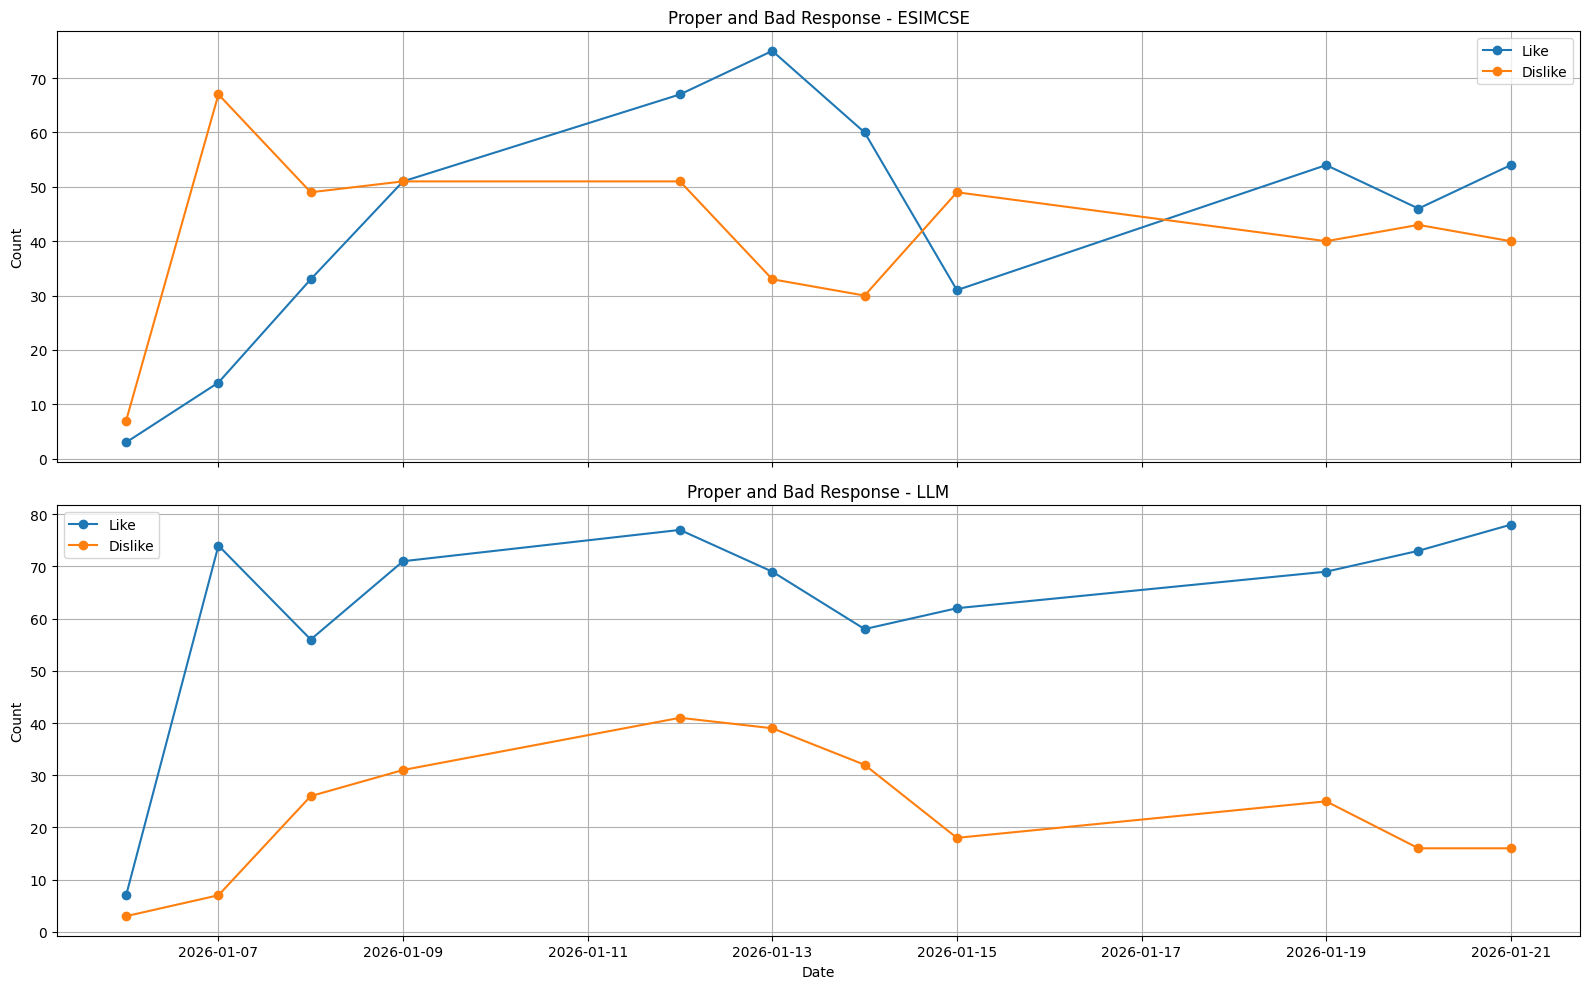

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# =========================
# ESIMCSE
# =========================
axes[0].plot(esimcse_daily.index, esimcse_daily.get('Like', 0), label='Like', marker='o')
axes[0].plot(esimcse_daily.index, esimcse_daily.get('Dislike', 0), label='Dislike', marker='o')

axes[0].set_title('Proper and Bad Response - ESIMCSE')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True)

# =========================
# LLM
# =========================
axes[1].plot(llm_daily.index, llm_daily.get('Like', 0), label='Like', marker='o')
axes[1].plot(llm_daily.index, llm_daily.get('Dislike', 0), label='Dislike', marker='o')

axes[1].set_title('Proper and Bad Response - LLM')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

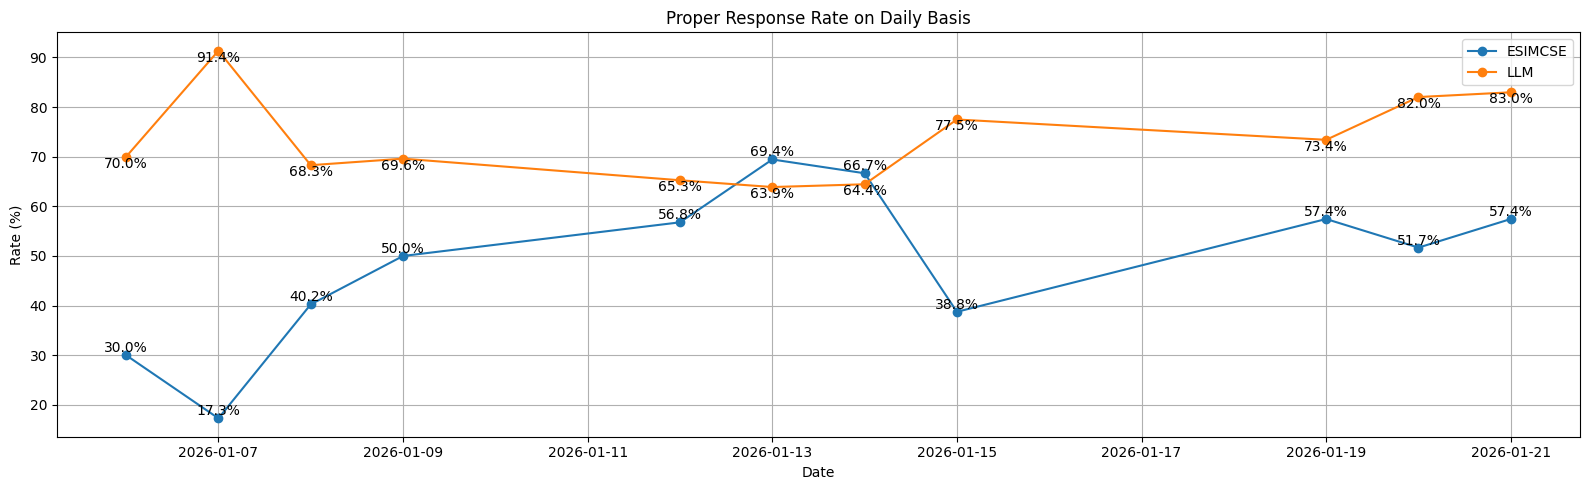

In [10]:
# Total ESIMCSE
total_esimcse = esimcse_daily['Like'] + esimcse_daily['Dislike']
esimcse_daily['like_pct'] = (esimcse_daily['Like'] / total_esimcse) * 100

#Total LLM
total_llm = llm_daily['Like'] + llm_daily['Dislike']
llm_daily['like_pct'] = (llm_daily['Like'] / total_llm) * 100

plt.figure(figsize=(16, 5))

# Plot lines
plt.plot(
    esimcse_daily.index,
    esimcse_daily['like_pct'],
    marker='o',
    label='ESIMCSE'
)

plt.plot(
    llm_daily.index,
    llm_daily['like_pct'],
    marker='o',
    label='LLM'
)

# =========================
# ADD VALUE LABELS
# =========================
for x, y in zip(esimcse_daily.index, esimcse_daily['like_pct']):
    plt.text(
        x, y,
        f'{y:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

for x, y in zip(llm_daily.index, llm_daily['like_pct']):
    plt.text(
        x, y,
        f'{y:.1f}%',
        ha='center',
        va='top',
        fontsize=10
    )

# Styling
plt.title('Proper Response Rate on Daily Basis')
plt.ylabel('Rate (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

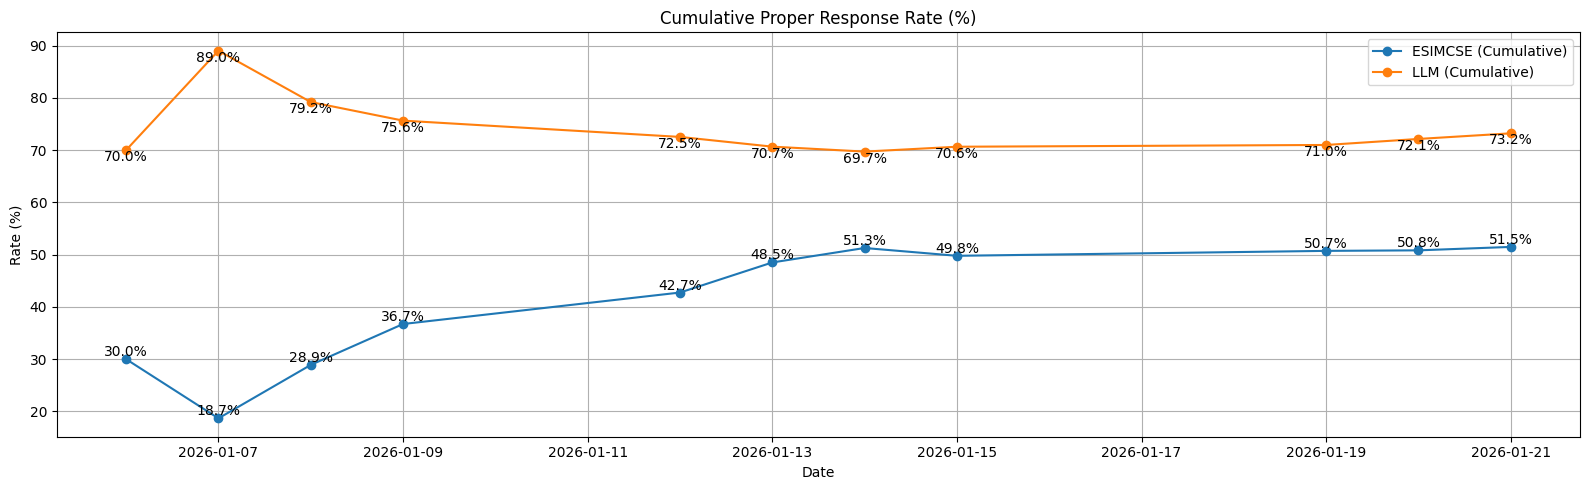

In [11]:
# =========================
# CUMULATIVE ESIMCSE
# =========================
esimcse_daily['cum_like'] = esimcse_daily['Like'].cumsum()
esimcse_daily['cum_total'] = total_esimcse.cumsum()
esimcse_daily['cum_like_pct'] = (
    esimcse_daily['cum_like'] / esimcse_daily['cum_total']
) * 100


# =========================
# CUMULATIVE LLM
# =========================
llm_daily['cum_like'] = llm_daily['Like'].cumsum()
llm_daily['cum_total'] = total_llm.cumsum()
llm_daily['cum_like_pct'] = (
    llm_daily['cum_like'] / llm_daily['cum_total']
) * 100

plt.figure(figsize=(16, 5))

plt.plot(
    esimcse_daily.index,
    esimcse_daily['cum_like_pct'],
    marker='o',
    label='ESIMCSE (Cumulative)'
)

plt.plot(
    llm_daily.index,
    llm_daily['cum_like_pct'],
    marker='o',
    label='LLM (Cumulative)'
)

# Value labels
for x, y in zip(esimcse_daily.index, esimcse_daily['cum_like_pct']):
    plt.text(x, y, f'{y:.1f}%', ha='center', va='bottom', fontsize=10)

for x, y in zip(llm_daily.index, llm_daily['cum_like_pct']):
    plt.text(x, y, f'{y:.1f}%', ha='center', va='top', fontsize=10)

plt.title('Cumulative Proper Response Rate (%)')
plt.ylabel('Rate (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Pipeline B

In [2]:
SERVICE_ACCOUNT_FILE = '../../key/credentials.json'
SCOPES = ['https://www.googleapis.com/auth/spreadsheets',
          'https://www.googleapis.com/auth/drive']

creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
client = gspread.authorize(creds)

sheet = client.open('LLM Kula').worksheet('data_LLM')
data = sheet.get_all_values()

df = pd.DataFrame(data[2:], columns=data[1])
df.to_csv('../../raw_data/llm_qc.csv', index=False)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1843 entries, 0 to 1842
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   date                1843 non-null   object
 1   validator           1843 non-null   object
 2   scenario_category   1843 non-null   object
 3   sub_category        1843 non-null   object
 4   detail_category     1843 non-null   object
 5   Result              1843 non-null   object
 6   LLM_dislike_reason  1843 non-null   object
dtypes: object(7)
memory usage: 100.9+ KB


In [4]:
df_clean = df[['date', 'Result']].copy()

df_clean.columns = df_clean.columns.str.lower()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['result'] = df_clean['result'].astype('category')

df_clean

,date,result
0,2026-01-22,Like
1,2026-01-22,Like
2,2026-01-22,Dislike
3,2026-01-22,Like
4,2026-01-22,Like
...,...,...
1838,2026-02-26,Like
1839,2026-02-26,Like
1840,2026-02-26,Like
1841,2026-02-26,Like


In [30]:
llm_daily = (
    df_clean.groupby(['date', 'result'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# lowerin columns name
llm_daily.columns = llm_daily.columns.str.lower()

# adding total column
llm_daily['total'] = llm_daily.sum(axis=1)

# cumulative sum
llm_daily['cum_like'] = llm_daily['like'].cumsum()
llm_daily['cum_total'] = llm_daily['total'].cumsum()

# cumulative percentage
llm_daily['cum_like_pct'] = round((
    llm_daily['cum_like'] / llm_daily['cum_total']
) * 100, 2)

llm_daily

C:\Users\ozy.prazuganda\AppData\Local\Temp\ipykernel_2464\1678977975.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(['date', 'result'])


result,dislike,like,total,cum_like,cum_total,cum_like_pct
date,,,,,,
2026-01-22,27,53,80,53,80,66.25
2026-01-23,23,37,60,90,140,64.29
2026-01-26,17,43,60,133,200,66.50
2026-01-27,22,58,80,191,280,68.21
2026-01-28,28,52,80,243,360,67.50
2026-01-29,21,59,80,302,440,68.64
2026-01-30,20,60,80,362,520,69.62
2026-02-02,19,61,80,423,600,70.50
2026-02-03,14,66,80,489,680,71.91


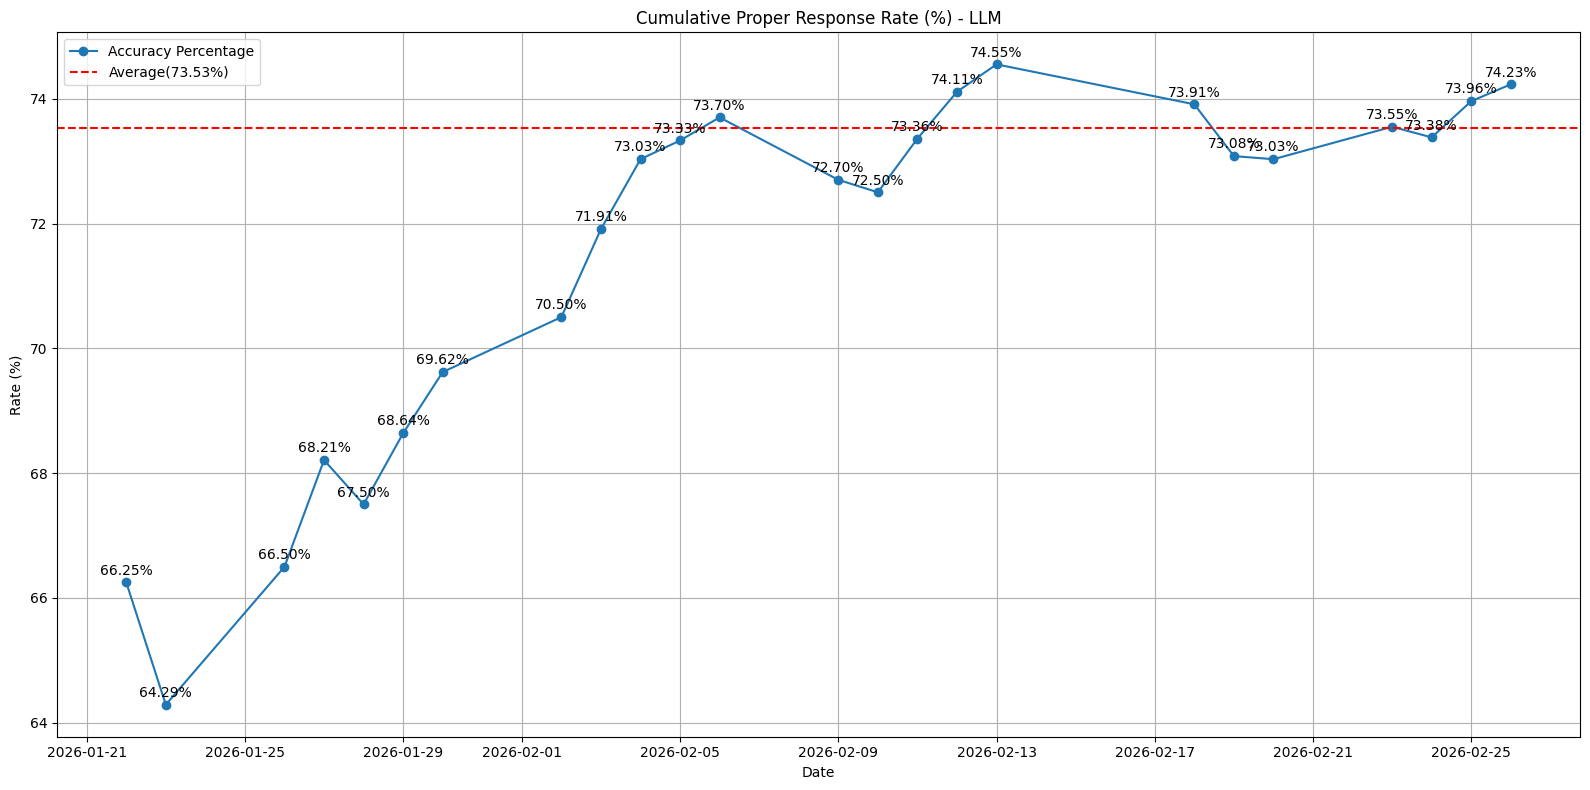

In [ ]:
fig = plt.figure(figsize=(16, 8))

plt.plot(
    llm_daily.index, 
    llm_daily.get('cum_like_pct', 0), 
    label='Accuracy Percentage', 
    marker = 'o'
)

# mean line
mean_pct = llm_daily['cum_like_pct'].tail(14).mean()

plt.axhline(
    y=mean_pct,
    color='red',
    linestyle='--',
    label=f'Average({mean_pct:.2f}%)'
)

# adding percentage labels
for x, y in zip(llm_daily.index, llm_daily['cum_like_pct']):
    plt.text(x, y + 0.3, f'{y:.2f}%', ha='center', va='top')



plt.title('Cumulative Proper Response Rate (%) - LLM')
plt.ylabel('Rate (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()